## Chargement des packages 


In [4]:
library(tidyverse)    
library(ggplot2)      
library(corrplot)     
library(FactoMineR)   
library(factoextra)   
library(vcd)          
library(GGally)       
library(moments)      
library(gridExtra)    

# Analyse exploratoire des données 

## 1. Chargement et vérification des données 

In [5]:
df <- read.csv("healthcare_synthetic_data.csv", stringsAsFactors = FALSE)


#### 1.1 Dimensions et aperçu général 

In [5]:
head(df)
cat("Dimensions du dataset: ",dim(df))
anyDuplicated(df$ID_patient)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


Dimensions du dataset:  15000 19

[1] 0

Le jeu de données contient bien **15 000 patients** (nombre de ligne) et **19 variables** (nombre de colonne).  
La variable `Patient_ID` est un identifiant unique : elle sera **supprimée** pour l'analyse. On vérifie que la colonne Patient_ID est a valeur unique avec la commande
**anyDuplicated** retournant 0 si il n'y a pas de doublons.
Les variables qualitatives sont déjà encodées sous forme d'entiers, il faudra les convertir en **facteurs** pour que R les traite correctement.

In [6]:
str(df)
cat("\nValeurs manquantes par variable :\n")
print(colSums(is.na(df)))
df <- df %>% select(-Patient_ID)

'data.frame':	15000 obs. of  19 variables:
 $ Patient_ID             : chr  "PID-00001" "PID-00002" "PID-00003" "PID-00004" ...
 $ Age                    : int  60 53 62 73 52 52 73 64 49 61 ...
 $ Gender                 : int  0 0 1 1 1 0 0 0 0 1 ...
 $ Height_cm              : num  147 162 175 173 179 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 79.8 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 25 23.7 25 34.5 28.2 36.3 ...
 $ Systolic_BP            : int  140 128 141 136 122 134 149 129 139 131 ...
 $ Diastolic_BP           : int  89 81 100 96 80 92 98 90 91 91 ...
 $ Cholesterol_Total      : int  217 203 173 193 236 225 260 237 227 206 ...
 $ Cholesterol_LDL        : int  151 119 124 117 153 155 166 160 138 139 ...
 $ Cholesterol_HDL        : int  52 38 45 45 41 48 46 44 37 38 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 79 103 103 108 90 103 ...
 $ Smoking_Status         : int  0 0 0 0 0 0 0 0 1 0 ...
 $ Alcohol_Consumption    : int  1 0 0 0 1 0 0 1 0 

Aucune valeur manquante n'est détectée dans le jeu de données.  
La variable `Patient_ID` a été supprimée car elle n'apporte aucune information prédictive.

Les variables qualitatives suivantes sont encodées en entiers et doivent être converties en facteurs :

| Variable                   | Encodage                                          |
| -------------------------- | ------------------------------------------------- |
| `Genre`                    | 0 = Femme, 1 = Homme                              |
| `Statut_Tabac`             | 0 = Non-fumeur, 1 = Fumeur                        |
| `Consommation_Alcool`      | 0 = Aucune, 1 = Modérée, 2 = Élevée               |
| `Niveau_Activité_Physique` | 0 = Aucun, 1 = Faible, 2 = Modéré, 3 = Élevé |
| `Antécédents_Familiaux`    | 0 = Non, 1 = Oui                                  |
| `Risque_Maladie_Cardiaque` | 0 = Risque faible, 1 = Risque élevé               |


#### 1.2 Conversion des variables qualitatives

In [6]:
df[,"Smoking_Status"]<- as.factor(df[,"Smoking_Status"])
df[,"Gender"]<- as.factor(df[,"Gender"])
df[,"Family_History"]<- as.factor(df[,"Family_History"])
df[,"Heart_Disease_Risk"]<- as.factor(df[,"Heart_Disease_Risk"])
df[,"Alcohol_Consumption"]<- as.factor(df[,"Alcohol_Consumption"])
df[,"Physical_Activity_Level"]<- as.factor(df[,"Physical_Activity_Level"])

#### 1.3 Statistique descriptive 

In [68]:
summary(df)

      Age        Gender     Height_cm       Weight_kg           BMI       
 Min.   :25.00   0:7622   Min.   :138.5   Min.   : 33.70   Min.   :14.50  
 1st Qu.:46.00   1:7378   1st Qu.:158.5   1st Qu.: 65.20   1st Qu.:24.50  
 Median :55.00            Median :164.7   Median : 73.90   Median :27.20  
 Mean   :54.54            Mean   :165.3   Mean   : 75.25   Mean   :27.45  
 3rd Qu.:63.00            3rd Qu.:172.0   3rd Qu.: 83.90   3rd Qu.:30.00  
 Max.   :85.00            Max.   :198.1   Max.   :150.10   Max.   :46.10  
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0     3rd Qu.:152.0  
 Max.   :182.0   Max.   :120.00   Max.   :303.0     Max.   :210.0  

##### 1.3.1 Statistque unidimensionnelle

Warning message:
"The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead."
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


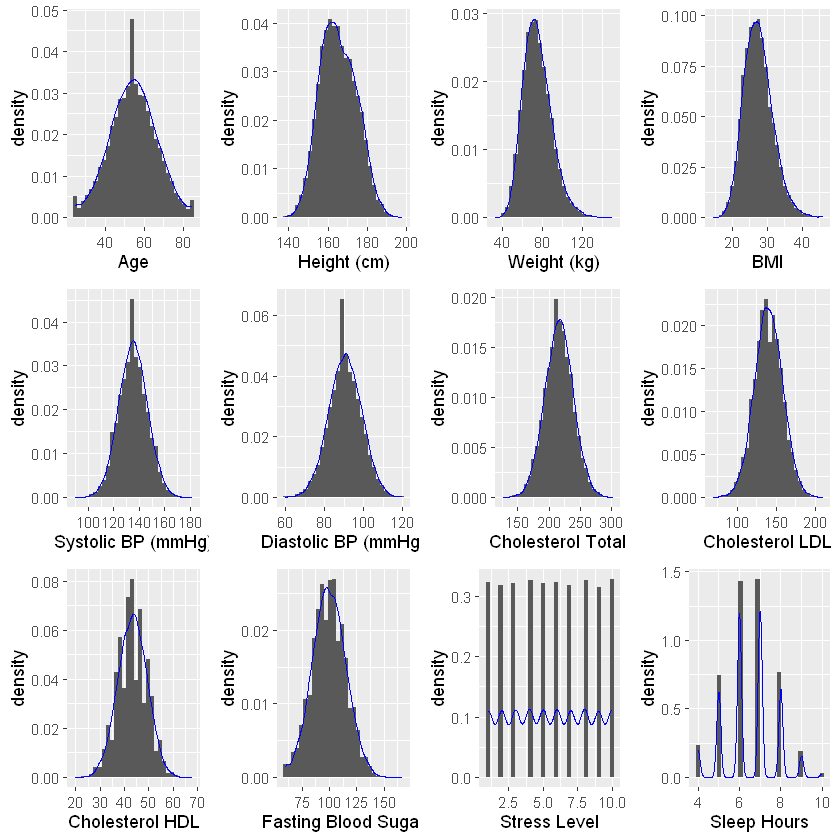

In [7]:
g1  <- ggplot(df, aes(x=df[,"Age"]))               + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Age")              
g2  <- ggplot(df, aes(x=df[,"Height_cm"]))         + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Height (cm)")      
g3  <- ggplot(df, aes(x=df[,"Weight_kg"]))         + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Weight (kg)")      
g4  <- ggplot(df, aes(x=df[,"BMI"]))               + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("BMI")               
g5  <- ggplot(df, aes(x=df[,"Systolic_BP"]))       + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Systolic BP (mmHg)") 
g6  <- ggplot(df, aes(x=df[,"Diastolic_BP"]))      + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Diastolic BP (mmHg)")
g7  <- ggplot(df, aes(x=df[,"Cholesterol_Total"])) + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Cholesterol Total")  
g8  <- ggplot(df, aes(x=df[,"Cholesterol_LDL"]))   + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Cholesterol LDL")   
g9  <- ggplot(df, aes(x=df[,"Cholesterol_HDL"]))   + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Cholesterol HDL")    
g10 <- ggplot(df, aes(x=df[,"Fasting_Blood_Sugar"]))+ geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Fasting Blood Sugar")
g11 <- ggplot(df, aes(x=df[,"Stress_Level"]))      + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Stress Level")       
g12 <- ggplot(df, aes(x=df[,"Sleep_Hours"]))       + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Sleep Hours")        
grid.arrange(g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,g11,g12, ncol=4)
rm(g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,g11,g12)

- `Age`, `Height_cm`, `Systolic_BP`, `Diastolic_BP`, `Cholesterol_Total`, `Cholesterol_LDL`, `Fasting_Blood_Sugar` et `BMI` présentent des distributions quasi-symétriques, proches d'une loi normale. Aucune transformation ne semble nécessaire pour ces variables.
- `Weight_kg` et `Cholesterol_HDL` présentent une légère asymétrie à gauche, mais elle reste suffisamment modérée pour ne pas justifier une transformation logarithmique.
- `Stress_Level` et `Sleep_Hours` ont des distributions discrètes et quasi-uniformes, ce sont des variables d'échelle entière (1 à 10 et 4 à 10), ce qui explique l'aspect en "peigne" de leurs histogrammes. Ces variables ne suivent pas une loi normale.


Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information."


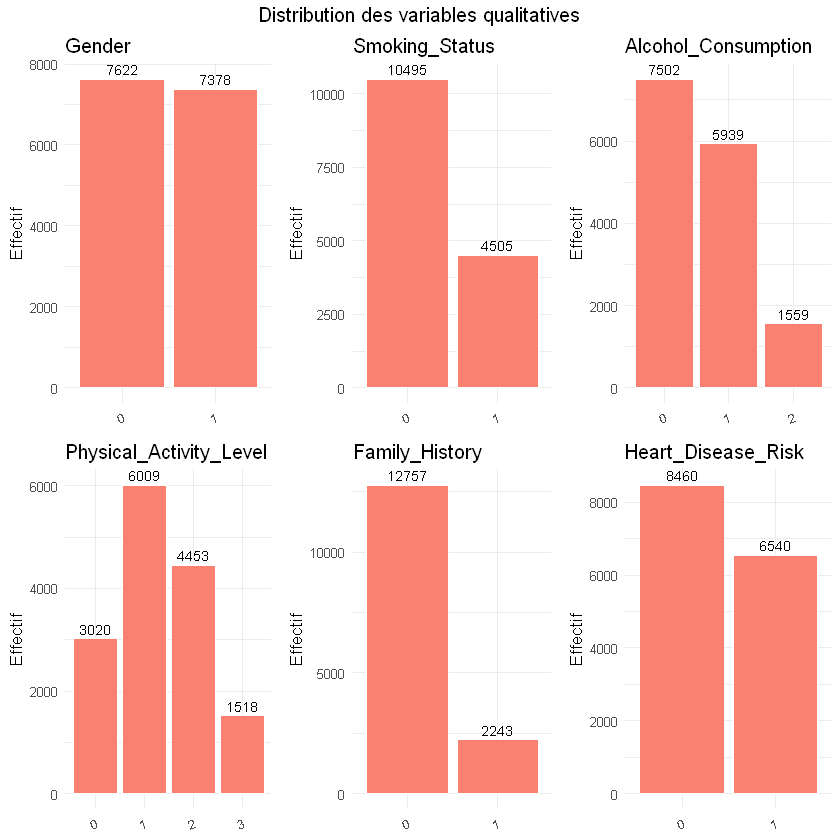

In [8]:

cat_cols <- c("Gender", "Smoking_Status", "Alcohol_Consumption",
              "Physical_Activity_Level", "Family_History", "Heart_Disease_Risk")

plots_qual <- lapply(cat_cols, function(col) {
  ggplot(df, aes_string(x = col)) +
    geom_bar(fill = "salmon", color = "white") +
    geom_text(stat = "count", aes(label = after_stat(count)),
              vjust = -0.4, size = 3) +
    labs(title = col, x = NULL, y = "Effectif") +
    theme_minimal(base_size = 10) +
    theme(axis.text.x = element_text(angle = 20, hjust = 1))
})

grid.arrange(grobs = plots_qual, ncol = 3,
             top = "Distribution des variables qualitatives")

**Distribution des variables qualitatives**

- `Gender` : répartition équilibrée entre les deux modalités.
- `Smoking_Status` : large majorité de non-fumeurs dans la population étudiée.
- `Alcohol_Consumption` : la modalité 0 (aucune consommation) est majoritaire, suivie de la consommation modérée puis élevée.
- `Physical_Activity_Level` : les quatre niveaux d'activité sont relativement bien répartis, avec une légère surreprésentation des niveaux intermédiaires.
- `Family_History` : les antécédents familiaux de maladie cardiaque concernent une minorité de patients.
- `Heart_Disease_Risk` : environ 43.6% des patients présentent un risque élevé, les classes sont suffisamment équilibrées pour éviter tout problème de déséquilibre majeur en modélisation.

#### Statistique bidimensionnelle

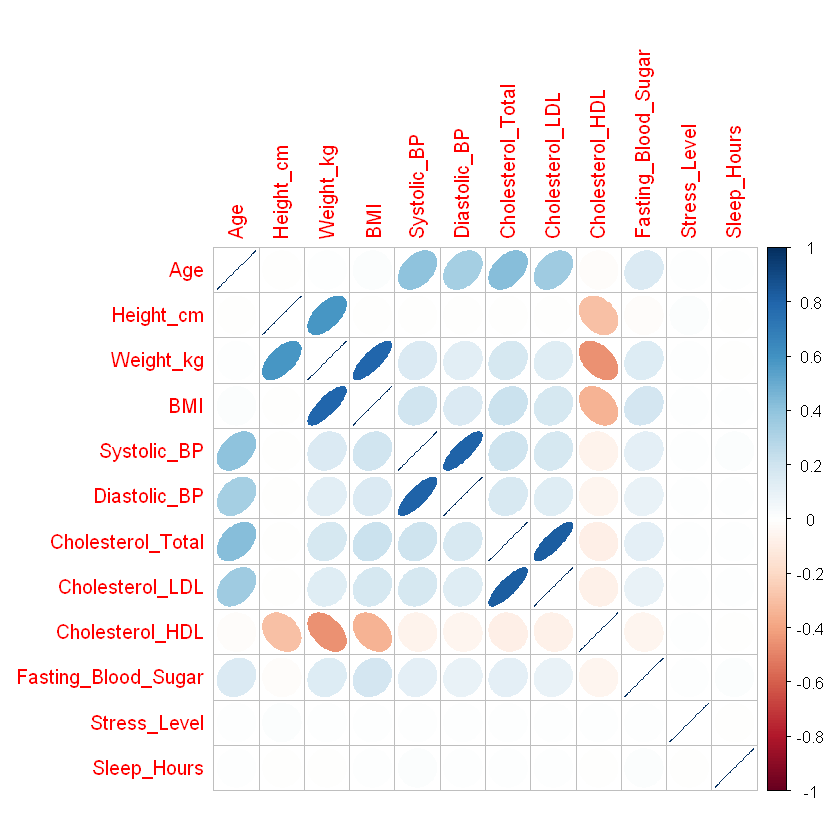

In [ ]:
# Regroupement des variables quantitatives dans une matrice 
quant_cols <- c("Age", "Height_cm", "Weight_kg", "BMI",
                "Systolic_BP", "Diastolic_BP", "Cholesterol_Total",
                "Cholesterol_LDL", "Cholesterol_HDL",
                "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours")

# Matrice de corrélation 
corrplot(cor(df_encoded[, quant_cols]), method="ellipse")

La corrélation la plus forte et la plus attendue est celle entre `Weight_kg` et `BMI` (corrélation positive très élevée, ellipse très allongée en bleu foncé), ce qui est logique puisque le BMI est directement calculé à partir du poids. On observe également une corrélation positive notable entre `Cholesterol_Total` et `Cholesterol_LDL`, confirmant que le "mauvais" cholestérol constitue la composante principale du cholestérol total, ainsi qu'une corrélation positive entre `Systolic_BP` et `Diastolic_BP`, cohérente médicalement. En revanche, la grande majorité des autres paires de variables présentent des corrélations très faibles voire nulles, ce qui indique une indépendance majoritaire entre les variables.

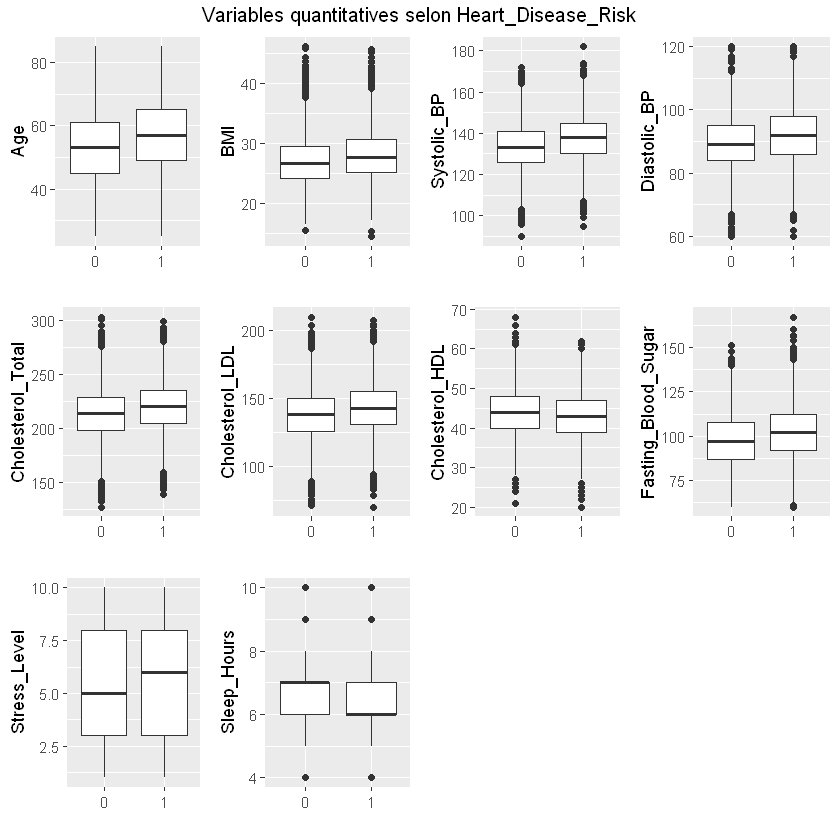

In [13]:
g1  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Age"]))             + geom_boxplot() + xlab("") + ylab("Age")
g2  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "BMI"]))             + geom_boxplot() + xlab("") + ylab("BMI")
g3  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Systolic_BP"]))     + geom_boxplot() + xlab("") + ylab("Systolic_BP")
g4  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Diastolic_BP"]))    + geom_boxplot() + xlab("") + ylab("Diastolic_BP")
g5  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Cholesterol_Total"]))+ geom_boxplot()+ xlab("") + ylab("Cholesterol_Total")
g6  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Cholesterol_LDL"])) + geom_boxplot() + xlab("") + ylab("Cholesterol_LDL")
g7  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Cholesterol_HDL"])) + geom_boxplot() + xlab("") + ylab("Cholesterol_HDL")
g8  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Fasting_Blood_Sugar"]))+ geom_boxplot()+ xlab("") + ylab("Fasting_Blood_Sugar")
g9  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Stress_Level"]))    + geom_boxplot() + xlab("") + ylab("Stress_Level")
g10 <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Sleep_Hours"]))     + geom_boxplot() + xlab("") + ylab("Sleep_Hours")

grid.arrange(g1, g2, g3, g4, g5, g6, g7, g8, g9, g10, ncol = 4,
             top = "Variables quantitatives selon Heart_Disease_Risk")
rm(g1, g2, g3, g4, g5, g6, g7, g8, g9, g10)

`Age` et `Stress_Level` sont les variables qui montrent la différence la plus visible entre les deux groupes, les patients à risque élevé (1) sont en moyenne plus âgés et plus stressés.
`Systolic_BP`, `Cholesterol_LDL` et `Fasting_Blood_Sugar` présentent également une légère tendance à des valeurs plus élevées chez les patients à risque, ce qui est cohérent médicalement. En revanche, `BMI`, `Diastolic_BP`, `Cholesterol_Total`, `Cholesterol_HDL` et `Sleep_Hours` montrent des distributions quasi-identiques entre les deux groupes, suggérant un faible pouvoir discriminant univarié pour ces variables.

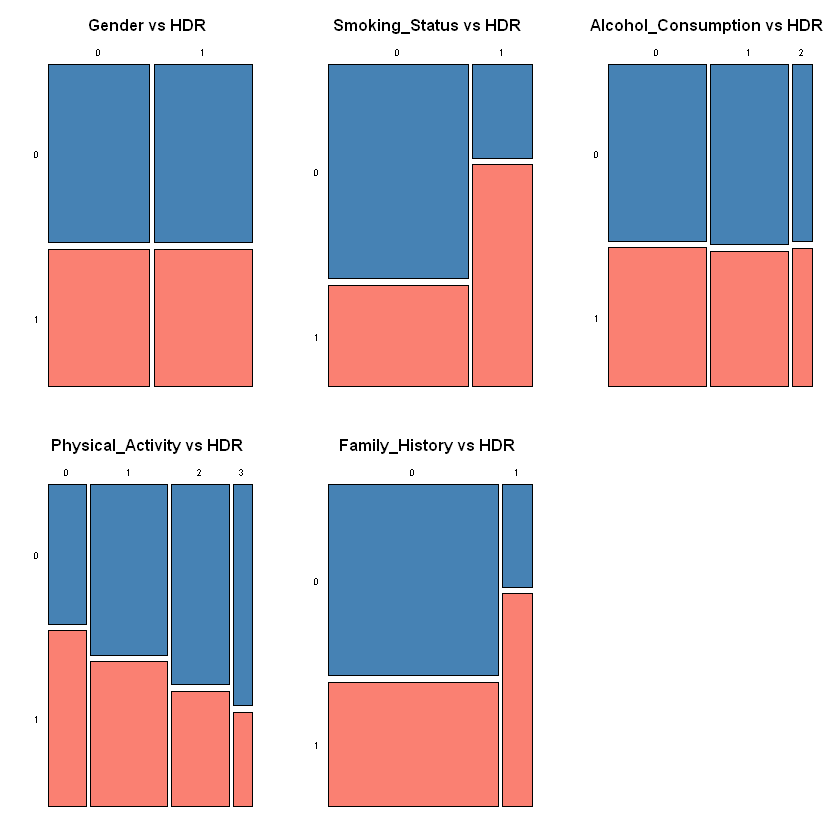

In [16]:
par(mfrow = c(2, 3), mar = c(2, 2, 3, 1))
mosaicplot(table(df[, "Gender"],                 df[, "Heart_Disease_Risk"]),
           main = "Gender vs HDR",                color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Smoking_Status"],          df[, "Heart_Disease_Risk"]),
           main = "Smoking_Status vs HDR",         color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Alcohol_Consumption"],     df[, "Heart_Disease_Risk"]),
           main = "Alcohol_Consumption vs HDR",    color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Physical_Activity_Level"], df[, "Heart_Disease_Risk"]),
           main = "Physical_Activity vs HDR",      color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Family_History"],          df[, "Heart_Disease_Risk"]),
           main = "Family_History vs HDR",         color = c("steelblue", "salmon"), las = 1)
par(mfrow = c(1, 1))

- `Gender` et `Alcohol_Consumption` montrent une proportionnalité au niveau des rectangles, révélant ainsi peu de dépendance avec `Heart_Disease_Risk`.
- `Physical_Activity` montre une tendance descendante : l'augmentation du niveau d'activité physique s'accompagne d'une diminution du risque de maladie cardiaque.
- `Family_History` et `Smoking_Status` révèlent une dépendance claire avec `Heart_Disease_Risk`, les patients ayant des antécédents familiaux ou étant fumeurs sont proportionnellement plus à risque élevé.